In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

## objective

**The goal is to predict whether a client will subscribe to a bank term deposit**

age: Age of the client (numeric)

job: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)

marital: Marital status (categorical: "married", "single", "divorced")

education: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")

default: Has credit in default? (categorical: "yes", "no")

balance: Average yearly balance in euros (numeric)

housing: Has a housing loan? (categorical: "yes", "no")

loan: Has a personal loan? (categorical: "yes", "no")

contact: Type of communication contact (categorical: "unknown", "telephone", "cellular")

day: Last contact day of the month (numeric, 1-31)

month: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")

duration: Last contact duration in seconds (numeric)

campaign: Number of contacts performed during this campaign (numeric)

pdays: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)

previous: Number of contacts performed before this campaign (numeric)

poutcome: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")

y: The target variable, whether the client subscribed to a term deposit (binary: "yes", "no")

## Dataset overview

In [13]:
data = pd.read_csv('data/train.csv')
print(data.shape)
data.head()

(750000, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


### understanding categorical values

In [15]:
cat_cols = data.select_dtypes(exclude=['int64']).columns
for i in cat_cols:
    print(f'{i} categories:', data[i].unique())

job categories: ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
marital categories: ['married' 'single' 'divorced']
education categories: ['secondary' 'primary' 'tertiary' 'unknown']
default categories: ['no' 'yes']
housing categories: ['no' 'yes']
loan categories: ['no' 'yes']
contact categories: ['cellular' 'unknown' 'telephone']
month categories: ['aug' 'jun' 'may' 'feb' 'apr' 'nov' 'jul' 'jan' 'oct' 'mar' 'sep' 'dec']
poutcome categories: ['unknown' 'other' 'failure' 'success']


In [16]:
data['contact'] = data['contact'].replace('unknown', 'unknown_contact')
data['poutcome'] = data['poutcome'].replace('unknown', 'unknown_poutcome')

In [17]:
# change month categories to number of month
month_num = {'jan':1,
             'feb':2,
             'mar':3,
             'apr':4,
             'may':5,
             'jun':6,
             'jul':7,
             'aug':8,
             'sep':9,
             'oct':10,
             'nov':11,
             'dec':12}

data['month'] = data['month'].map(month_num)

In [18]:
data = data.rename({'y':'deposit'},axis=1)
data.head(2)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,8,117,3,-1,0,unknown_poutcome,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown_contact,18,6,185,1,-1,0,unknown_poutcome,0


### data viz

In [19]:
def cat_viz(x, y, kind, title):
    groupby = data.groupby(x)[y].sum()
    groupby.plot(kind=kind)
    plt.title(title)
    return plt.show()

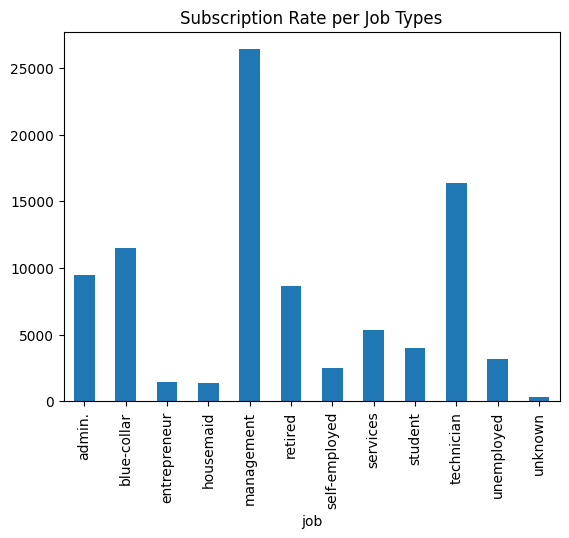

In [21]:
cat_viz('job', 'deposit','bar', "Subscription Rate per Job Types")

students are more likely to subscribe to bank deposit

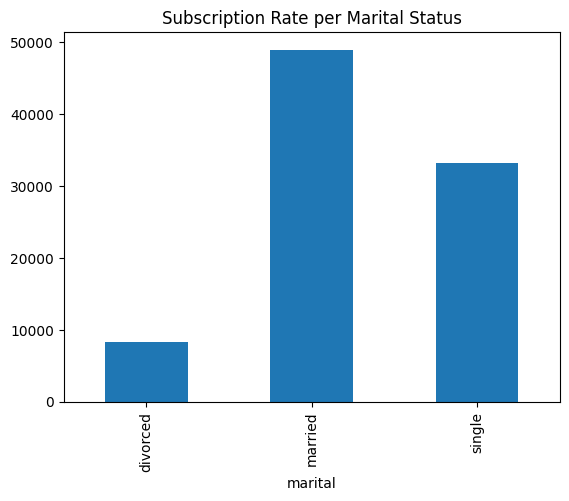

In [22]:
cat_viz('marital','deposit', 'bar', "Subscription Rate per Marital Status")

apparently single people are more likely to subscribe to bank deposit

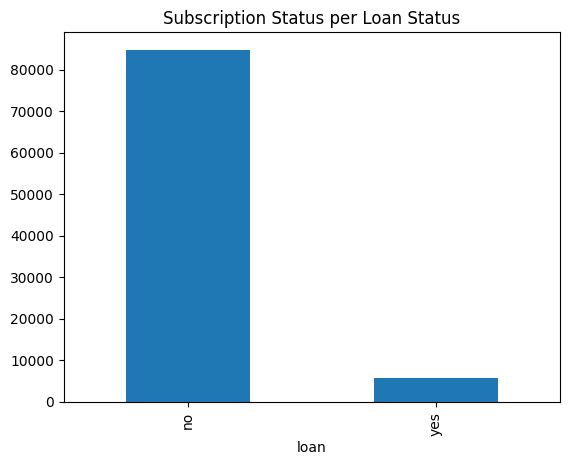

In [23]:
cat_viz('loan','deposit','bar', "Subscription Status per Loan Status")

customers who dont have loan are more likely to subscribe, because those who does might be prioritizing to pay their loan first

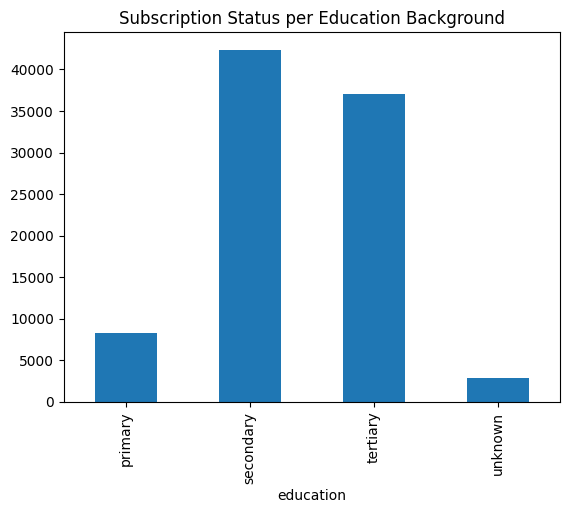

In [24]:
cat_viz('education','deposit','bar', "Subscription Status per Education Background")

customers with secondary educational background (bachelor's degree) might start to have awareness in saving money to build budgeting habit.

number of customers with tertiary background are slightly lower as they might have another medium to save money, such as investment, rather than depositing only.

Text(0.5, 1.0, 'Days of Campaign vs Subscription Status')

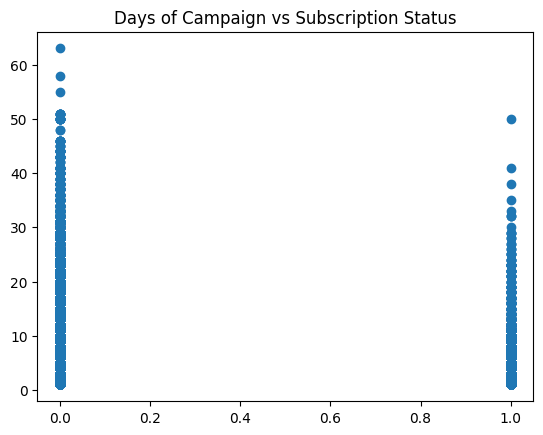

In [25]:
plt.scatter(data['deposit'], data['campaign'])
plt.title("Days of Campaign vs Subscription Status")

we can see that customers who don't subscribe yet get more campaigns than those who subscribed.

This makes sense because the bank still attempts to get new subscribers.

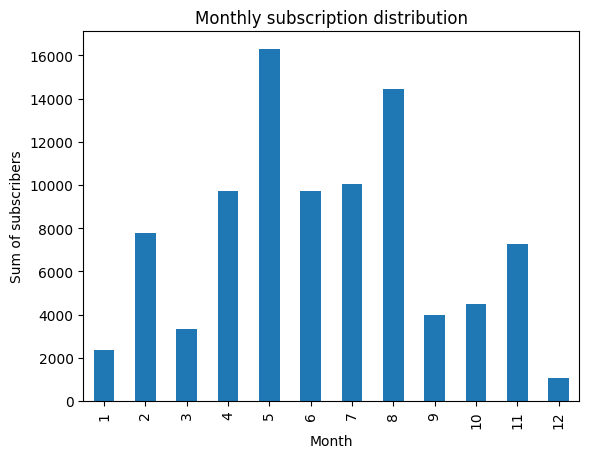

In [26]:
monthly_sum = data.groupby('month')['deposit'].sum()
monthly_sum.plot(kind='bar')
plt.xlabel("Month")
plt.ylabel("Sum of subscribers")
plt.title("Monthly subscription distribution")
plt.show()

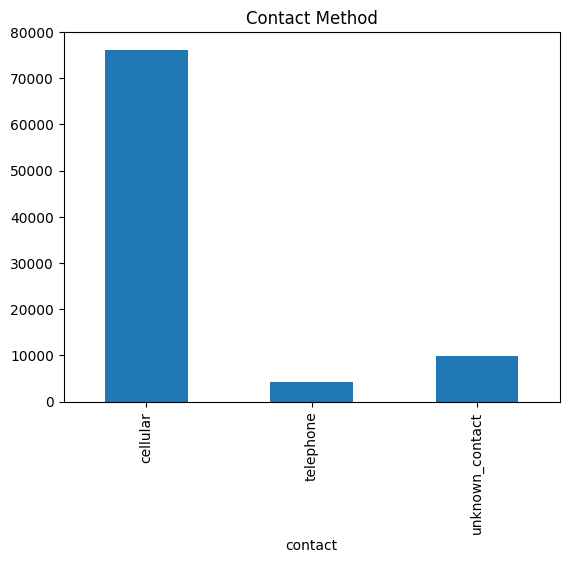

In [27]:
cat_viz('contact','deposit','bar', "Contact Method")

customers are more likely to subscribe if they are being contacted via cellular / smartphone

especially in most cases gen z are drawn towards simple notification / texts instead of telephone call

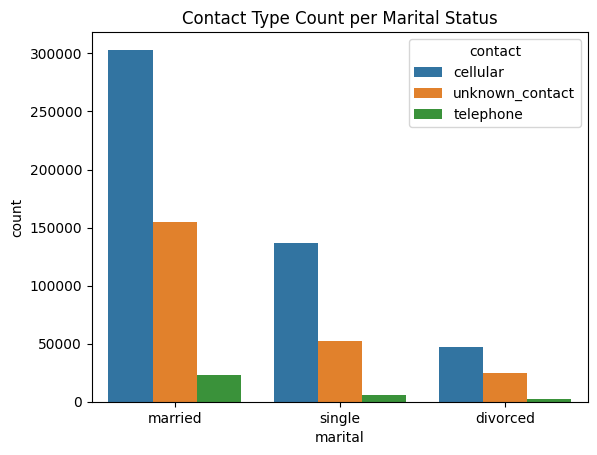

In [28]:
sns.countplot(data=data, x='marital', hue='contact')
plt.title("Contact Type Count per Marital Status")
plt.show()

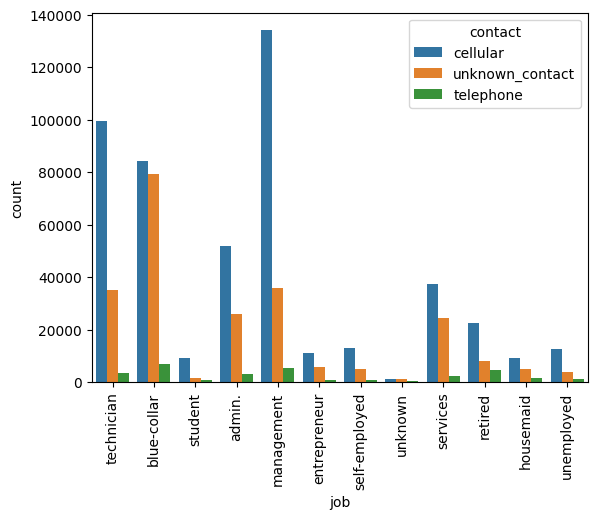

In [29]:
ax = sns.countplot(data=data, x='job', hue='contact')
plt.xticks(rotation=90)
plt.show()

we can see that no one likes being contacted via telephone :D

pdays: Number of days since the client was last contacted from a previous campaign

Text(0.5, 1.0, 'Days of Campaign vs Subscription Status')

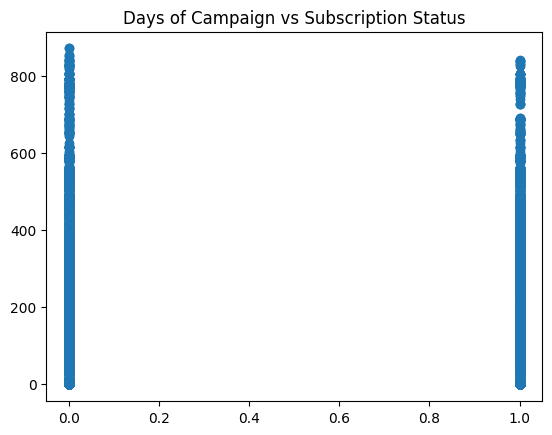

In [30]:
plt.scatter(data['deposit'], data['pdays'])
plt.title("Days of Campaign vs Subscription Status")

## encoding

In [34]:
data_encoded = data.copy()

### label encoding

In [35]:
yes_no_map = {'yes':1, 'no':0}
for i in cat_cols:
    if len(data[i].unique()) == 2:
        data_encoded[i] = data_encoded[i].map(yes_no_map)

data_encoded.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,0,42,technician,married,secondary,0,7,0,0,cellular,25,8,117,3,-1,0,unknown_poutcome,0
1,1,38,blue-collar,married,secondary,0,514,0,0,unknown_contact,18,6,185,1,-1,0,unknown_poutcome,0
2,2,36,blue-collar,married,secondary,0,602,1,0,unknown_contact,14,5,111,2,-1,0,unknown_poutcome,0
3,3,27,student,single,secondary,0,34,1,0,unknown_contact,28,5,10,2,-1,0,unknown_poutcome,0
4,4,26,technician,married,secondary,0,889,1,0,cellular,3,2,902,1,-1,0,unknown_poutcome,1


In [36]:
education_map = {'unknown':0,
                 'primary':1,
                 'secondary':2,
                 'tertiary':3}
data_encoded['education'] = data_encoded['education'].map(education_map)
data_encoded.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,0,42,technician,married,2,0,7,0,0,cellular,25,8,117,3,-1,0,unknown_poutcome,0
1,1,38,blue-collar,married,2,0,514,0,0,unknown_contact,18,6,185,1,-1,0,unknown_poutcome,0
2,2,36,blue-collar,married,2,0,602,1,0,unknown_contact,14,5,111,2,-1,0,unknown_poutcome,0
3,3,27,student,single,2,0,34,1,0,unknown_contact,28,5,10,2,-1,0,unknown_poutcome,0
4,4,26,technician,married,2,0,889,1,0,cellular,3,2,902,1,-1,0,unknown_poutcome,1


### one hot encode

In [37]:
onehot_col = ['marital','contact','poutcome']
data_encoded = pd.get_dummies(data_encoded, columns=onehot_col, dtype=int)
data_encoded.head()

,id,age,job,education,default,balance,housing,loan,day,month,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown_contact,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown_poutcome
0,0,42,technician,2,0,7,0,0,25,8,...,0,1,0,1,0,0,0,0,0,1
1,1,38,blue-collar,2,0,514,0,0,18,6,...,0,1,0,0,0,1,0,0,0,1
2,2,36,blue-collar,2,0,602,1,0,14,5,...,0,1,0,0,0,1,0,0,0,1
3,3,27,student,2,0,34,1,0,28,5,...,0,0,1,0,0,1,0,0,0,1
4,4,26,technician,2,0,889,1,0,3,2,...,0,1,0,1,0,0,0,0,0,1


### categorizing job column because it has >5 categories

#### by cluster

In [40]:
# data.groupby("job")["y"].mean().sort_values()
job_rates = (
    data.groupby("job")["deposit"].mean().reset_index()
    .rename(columns={"deposit": "target_rate"})
)

print(job_rates.sort_values(by='target_rate', ascending=True))

              job  target_rate
1     blue-collar     0.067438
2    entrepreneur     0.081386
7        services     0.082714
3       housemaid     0.084653
0          admin.     0.116453
9      technician     0.118321
11        unknown     0.120672
6   self-employed     0.129443
4      management     0.150392
10     unemployed     0.179823
5         retired     0.246241
8         student     0.340784


my concern about doing encoding based on kmeans clusters is that jobs with mid target rate is being considered as cluster 3.

3 is the highest number, so the model would possibly be biased towards them and will guess that these type of jobs will subscribe,

while the highest target rate is student.

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
job_rates["cluster"] = kmeans.fit_predict(job_rates[["target_rate"]])

job_rates = job_rates.sort_values("target_rate").reset_index(drop=True)
print(job_rates)

              job  target_rate  cluster
0     blue-collar     0.067438        0
1    entrepreneur     0.081386        0
2        services     0.082714        0
3       housemaid     0.084653        0
4          admin.     0.116453        3
5      technician     0.118321        3
6         unknown     0.120672        3
7   self-employed     0.129443        3
8      management     0.150392        3
9      unemployed     0.179823        2
10        retired     0.246241        2
11        student     0.340784        1


#### by target encoding

we'll do target encoding after splitting data, since this is like a cheatcode

## feature engineering

In [43]:
data_encoded["job_target_mean"] = data_encoded.groupby("job")["deposit"].transform("mean")

we see that job_target_mean has weak correlation to the target, but if we proceed to use this dataset for training, data leakage will occur. So, we'll drop job_target_mean column. We will do target encoding later after splitting data.

In [46]:
drop_col = ['job','id'] # not encoded yet
data_encoded_corr = data_encoded.drop(drop_col,axis=1).corr()
data_encoded_corr['deposit'].drop('deposit').sort_values(ascending=False)

duration                     0.519283
poutcome_success             0.306996
job_target_mean              0.157306
contact_cellular             0.149948
balance                      0.122513
previous                     0.119552
marital_single               0.090578
pdays                        0.089277
education                    0.071242
poutcome_other               0.020084
contact_telephone            0.010418
age                          0.009523
poutcome_failure             0.009432
month                       -0.001362
marital_divorced            -0.009246
default                     -0.030134
day                         -0.049625
campaign                    -0.075829
marital_married             -0.077038
loan                        -0.081639
housing                     -0.153589
contact_unknown_contact     -0.159455
poutcome_unknown_poutcome   -0.169538
Name: deposit, dtype: float64

## final data

In [47]:
print(data_encoded.shape)
data_encoded.head()

(750000, 26)


,id,age,job,education,default,balance,housing,loan,day,month,...,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown_contact,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown_poutcome,job_target_mean
0,0,42,technician,2,0,7,0,0,25,8,...,1,0,1,0,0,0,0,0,1,0.118321
1,1,38,blue-collar,2,0,514,0,0,18,6,...,1,0,0,0,1,0,0,0,1,0.067438
2,2,36,blue-collar,2,0,602,1,0,14,5,...,1,0,0,0,1,0,0,0,1,0.067438
3,3,27,student,2,0,34,1,0,28,5,...,0,1,0,0,1,0,0,0,1,0.340784
4,4,26,technician,2,0,889,1,0,3,2,...,1,0,1,0,0,0,0,0,1,0.118321


In [48]:
data_encoded.to_csv('data/data_model.csv',index=False)